### Proposta 9: Predição de Reincidência de Atendimento

#### Objetivo
Desenvolver um modelo de classificação **multi-output** que preveja:
- `30_dias` — se a OS terá reincidência em até 30 dias *(target primário)*
- `familia_descricao` — família do produto mais provável de reincidir
- `defeito_constatado_descricao` — defeito mais provável de reincidir

#### Modelos Utilizados
Decision Tree e Random Forest com `MultiOutputClassifier`.

## 1. Importação e Configuração do Ambiente

In [28]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Importar dados e Merge dos Dados

In [3]:
# Carregando os dados
os_base = Path.cwd() / 'dataset' / 'export_os_base.csv'
produtos = Path.cwd() / 'dataset' / 'export_produtos.csv'
defeito_solucao = Path.cwd() / 'dataset' / 'export_os_defeito_solucao.csv'
defeito_constatado = Path.cwd() / 'dataset' / 'export_defeitos_constatados.csv'

# Lendo os arquivos CSV
df_os_base = pd.read_csv(os_base)
df_produtos = pd.read_csv(produtos)
df_defeito_solucao = pd.read_csv(defeito_solucao)
df_defeito_constatado = pd.read_csv(defeito_constatado)

# Merges
df = df_os_base.merge(
    df_produtos[['produto_id', 'familia_descricao']], on='produto_id', how='left'
)
df = df.merge(
    df_defeito_solucao[['os_id_anonimo', 'defeito_constatado_id']], on='os_id_anonimo', how='left'
)
df = df.merge(
    df_defeito_constatado[['defeito_constatado_id', 'descricao']]
      .rename(columns={'descricao': 'defeito_constatado_descricao'}),
    on='defeito_constatado_id', how='left'
)

print(f'Shape após merges: {df.shape}')
df.head(3)

Shape após merges: (1246979, 14)


,os_id_anonimo,consumidor_id_anonimo,fabrica_id,data_abertura,data_fechamento,tipo_atendimento_id,posto_id_anonimo,tempo_resolucao_horas,concluida,estado,produto_id,familia_descricao,defeito_constatado_id,defeito_constatado_descricao
0,OS15b32ddd5992a0c829b9457ea6f6eea4,CONS-1a2dae77a98c395c0252c1d6c1445128,158,2022-01-01,2022-01-03,252,360786,62.416667,1,SP,414898.0,REFRIGERADOR,26826.0,Reator queimado
1,OS15b32ddd5992a0c829b9457ea6f6eea4,CONS-1a2dae77a98c395c0252c1d6c1445128,158,2022-01-01,2022-01-03,252,360786,62.416667,1,SP,414898.0,REFRIGERADOR,NaN,NaN
2,OSdc8508ed80212c356b1a9f4f1d03a239,CONS-1a2dae77a98c395c0252c1d6c1445128,158,2022-01-01,2022-01-02,252,620975,35.333333,1,RS,414204.0,REFRIGERADOR,28640.0,Controlador com defeito


## 3. Análise Exploratória dos Dados (EDA)

### 3.1 Informações Gerais do Dataset

In [6]:
print('=== INFORMAÇÕES GERAIS ===')
df.info()
print(f'\nShape: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246979 entries, 0 to 1246978
Data columns (total 14 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   os_id_anonimo                 1246979 non-null  object 
 1   consumidor_id_anonimo         1246979 non-null  object 
 2   fabrica_id                    1246979 non-null  int64  
 3   data_abertura                 1246979 non-null  object 
 4   data_fechamento               1243232 non-null  object 
 5   tipo_atendimento_id           1246979 non-null  int64  
 6   posto_id_anonimo              1246979 non-null  int64  
 7   tempo_resolucao_horas         1243232 non-null  float64
 8   concluida                     1246979 non-null  int64  
 9   estado                        1130915 non-null  object 
 10  produto_id                    1243429 non-null  float64
 11  familia_descricao             1243429 non-null  object 
 12  d

### 3.2 Duplicatas e Valores Faltantes

Duplicatas: 69665 (5.59%)

=== VALORES FALTANTES ===
                              Faltantes  % do Total
defeito_constatado_descricao     650753       52.19
defeito_constatado_id            625943       50.20
estado                           116064        9.31
tempo_resolucao_horas              3747        0.30
data_fechamento                    3747        0.30
familia_descricao                  3550        0.28
produto_id                         3550        0.28


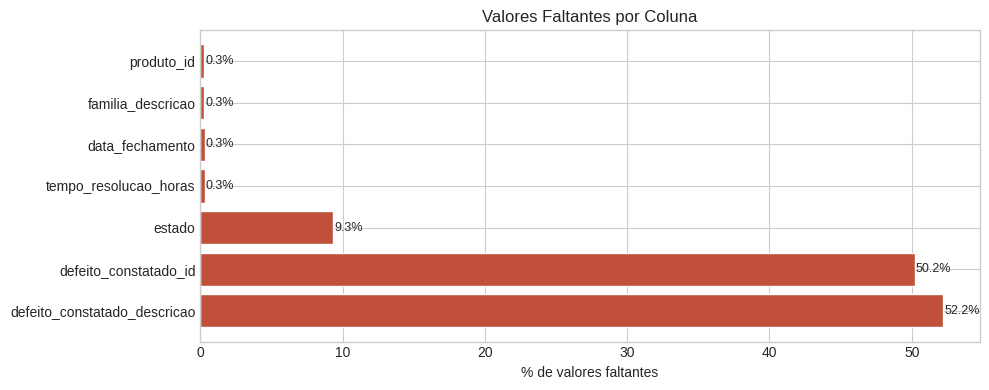

In [7]:
# Duplicatas
n_dup = df.duplicated().sum()
print(f'Duplicatas: {n_dup} ({n_dup/len(df)*100:.2f}%)')

# Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% do Total': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('% do Total', ascending=False)

if missing_df.empty:
    print('\nNenhum valor faltante encontrado!')
else:
    print('\n=== VALORES FALTANTES ===')
    print(missing_df.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(missing_df.index, missing_df['% do Total'],
                   color='#c0503a', edgecolor='white')
    for bar, v in zip(bars, missing_df['% do Total']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Valores Faltantes por Coluna')
    plt.tight_layout()
    plt.show()

### 3.3 Estatísticas Descritivas

In [8]:
print('=== COLUNAS NUMÉRICAS ===')
display(df.describe().round(2))

print('\n=== COLUNAS CATEGÓRICAS ===')
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    n_unique = df[col].nunique()
    top_val  = df[col].value_counts().index[0] if n_unique > 0 else 'N/A'
    print(f'  {col:<40} unique={n_unique:>6}   top={top_val}')

=== COLUNAS NUMÉRICAS ===


,fabrica_id,tipo_atendimento_id,posto_id_anonimo,tempo_resolucao_horas,concluida,produto_id,defeito_constatado_id
count,1246979.0,1246979.00,1246979.00,1243232.00,1246979.00,1243429.00,621036.00
mean,158.0,256.50,547680.15,139.05,1.00,702605.63,30640.41
std,0.0,8.51,248145.86,405.47,0.05,549676.47,5623.84
min,158.0,252.00,1035.00,6.68,0.00,413662.00,26814.00
25%,158.0,252.00,377321.00,34.50,1.00,414263.00,26843.00
50%,158.0,252.00,627863.00,46.69,1.00,414968.00,26859.00
75%,158.0,252.00,760445.00,114.00,1.00,632065.00,33748.00
max,158.0,277.00,878180.00,22620.00,1.00,2214220.00,59443.00



=== COLUNAS CATEGÓRICAS ===
  os_id_anonimo                            unique=556333   top=OSd0f6d85f86ef28f779293464d9b8f22b
  consumidor_id_anonimo                    unique=     1   top=CONS-1a2dae77a98c395c0252c1d6c1445128
  data_abertura                            unique=  1077   top=2023-08-15
  data_fechamento                          unique=  1280   top=2023-12-13
  estado                                   unique=    26   top=SP
  familia_descricao                        unique=     5   top=REFRIGERADOR
  defeito_constatado_descricao             unique=   209   top=Controlador com defeito


### 3.4 Outliers - Boxplot das Colunas Numéricas

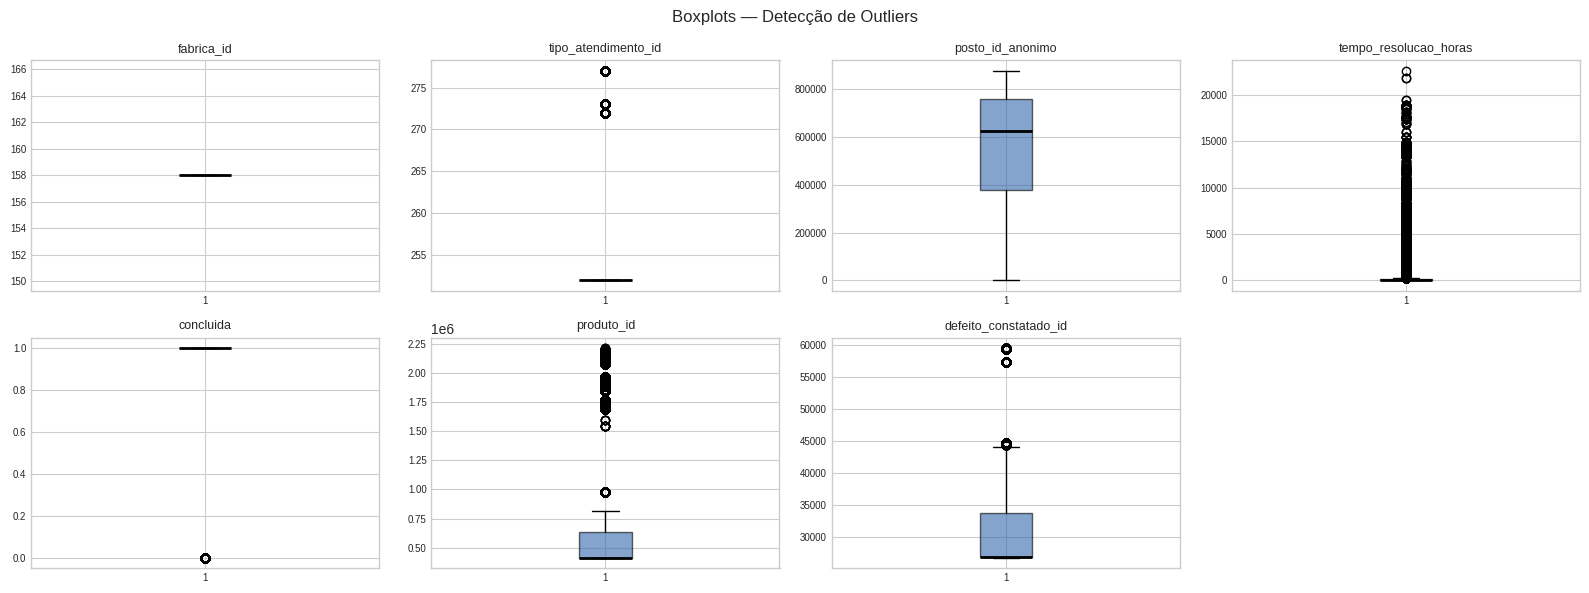

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if 'data' not in c.lower()]

if num_cols:
    ncols = 4
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        axes[i].boxplot(df[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='#3266ad', alpha=0.6),
                        medianprops=dict(color='black', linewidth=2))
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Boxplots — Detecção de Outliers', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Pré-Processamento e Engenharia de Features

### 4.1 Datas, consumidor_id_fake e Targets de Reincidência

In [10]:
# Análise temporal
df['data_abertura'] = pd.to_datetime(df['data_abertura'])
df['data_fechamento'] = pd.to_datetime(df['data_fechamento'])

df['consumidor_id_fake'] = np.random.randint(1, 80001, size=len(df))

# Ordenando por consumidor e data para calcular diferenças temporais
df = df.sort_values(['consumidor_id_fake', 'data_abertura'])
g  = df.groupby('consumidor_id_fake')['data_abertura']

for dias in [30, 60, 90]:
    df[f'{dias}_dias'] = (
        (g.diff() <= pd.Timedelta(days=dias)) |
        (g.diff(-1).abs() <= pd.Timedelta(days=dias))
    ).fillna(False).astype(int)

# Extraindo mês e ano para análise temporal
df['mes_abertura'] = df['data_abertura'].dt.month.astype('Int64')
df['ano_abertura'] = df['data_abertura'].dt.year.astype('Int64')
df['mes_fechamento'] = df['data_fechamento'].dt.month.astype('Int64')
df['ano_fechamento'] = df['data_fechamento'].dt.year.astype('Int64')
df['mes_sin'] = np.sin(2 * np.pi * df['mes_abertura'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes_abertura'] / 12)

# Criando variável de dias desde última OS para cada consumidor
df['dias_desde_ultima_os'] = (
    df['data_abertura'] - df.groupby('consumidor_id_fake')['data_abertura'].shift(1)
).dt.days

# Criando indicador de histórico para consumidores sem OS anterior
df['sem_historico'] = df['dias_desde_ultima_os'].isna().astype(int)
df['dias_desde_ultima_os'] = df['dias_desde_ultima_os'].fillna(-1)

# Filtrando para OS fechadas há mais de 30 dias para evitar viés temporal
data_max = df['data_fechamento'].max()
df = df[df['data_fechamento'] <= data_max - pd.Timedelta(days=30)]

print(f'Shape após filtro temporal: {df.shape}')

Shape após filtro temporal: (1243221, 26)


### 4.2 Limpeza de Colunas

In [11]:
# Removendo colunas com muitos valores faltantes ou irrelevantes
df.dropna(subset=['defeito_constatado_id', 'familia_descricao',
                  'defeito_constatado_descricao'], inplace=True)

drop_cols = [
    'fabrica_id', 'posto_id_anonimo', 'tempo_resolucao_horas',
    'estado', 'produto_id', 'tipo_atendimento_id',
    'consumidor_id_anonimo', 'data_abertura', 'data_fechamento',
    'defeito_constatado_id', '60_dias', '90_dias',
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df = df.sort_index()

print(f'Shape final: {df.shape}')
df.info()

Shape final: (595710, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 595710 entries, 0 to 1246977
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   os_id_anonimo                 595710 non-null  object 
 1   concluida                     595710 non-null  int64  
 2   familia_descricao             595710 non-null  object 
 3   defeito_constatado_descricao  595710 non-null  object 
 4   consumidor_id_fake            595710 non-null  int64  
 5   30_dias                       595710 non-null  int64  
 6   mes_abertura                  595710 non-null  Int64  
 7   ano_abertura                  595710 non-null  Int64  
 8   mes_fechamento                595710 non-null  Int64  
 9   ano_fechamento                595710 non-null  Int64  
 10  mes_sin                       595710 non-null  Float64
 11  mes_cos                       595710 non-null  Float64
 12  dias_desde_ultima_os  

### 4.3 Distribuição da Variável Target **30 dias** (pode ser alterado para 60 ou 90)

Razão desbalanceamento (0:1) = 0.7:1


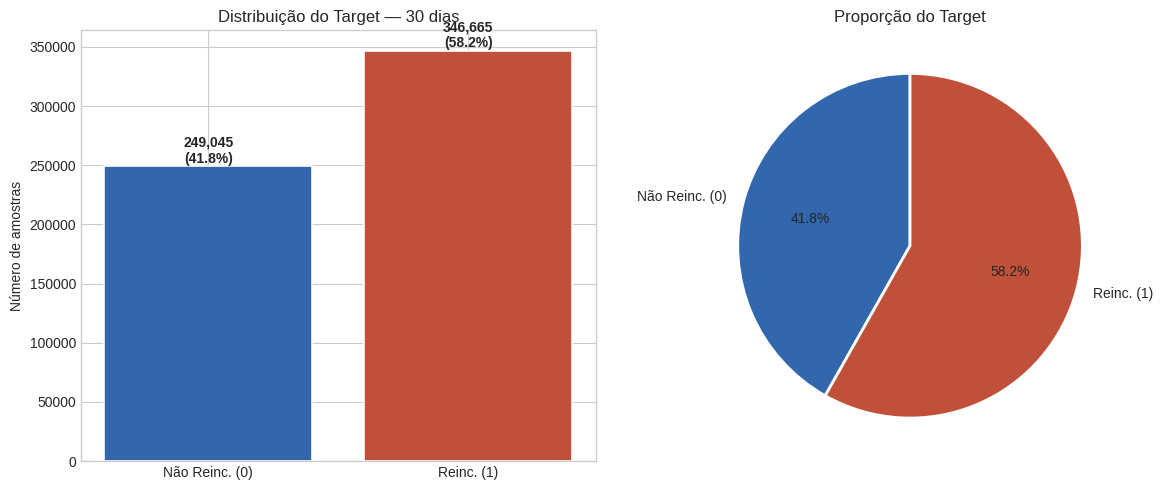

In [12]:
# Análise do target (pode ser alterado para 60_dias ou 90_dias conforme necessidade)
counts = df['30_dias'].value_counts()
labels = ['Não Reinc. (0)', 'Reinc. (1)']
values = [counts.get(0, 0), counts.get(1, 0)]
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(labels, values, color=['#3266ad', '#c0503a'],
                   edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribuição do Target — 30 dias')
axes[0].set_ylabel('Número de amostras')
for i, v in enumerate(values):
    pct = v / total * 100
    axes[0].text(i, v + total * 0.005, f'{v:,}\n({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['#3266ad', '#c0503a'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção do Target')

ratio = values[0] / values[1] if values[1] > 0 else float('inf')
print(f'Razão desbalanceamento (0:1) = {ratio:.1f}:1')
if ratio > 3:
    print('⚠ Dataset desbalanceado — class_weight="balanced" já aplicado nos modelos.')

plt.tight_layout()
plt.show()

### 4.4 Taxa de Reincidência por Feature Categórica

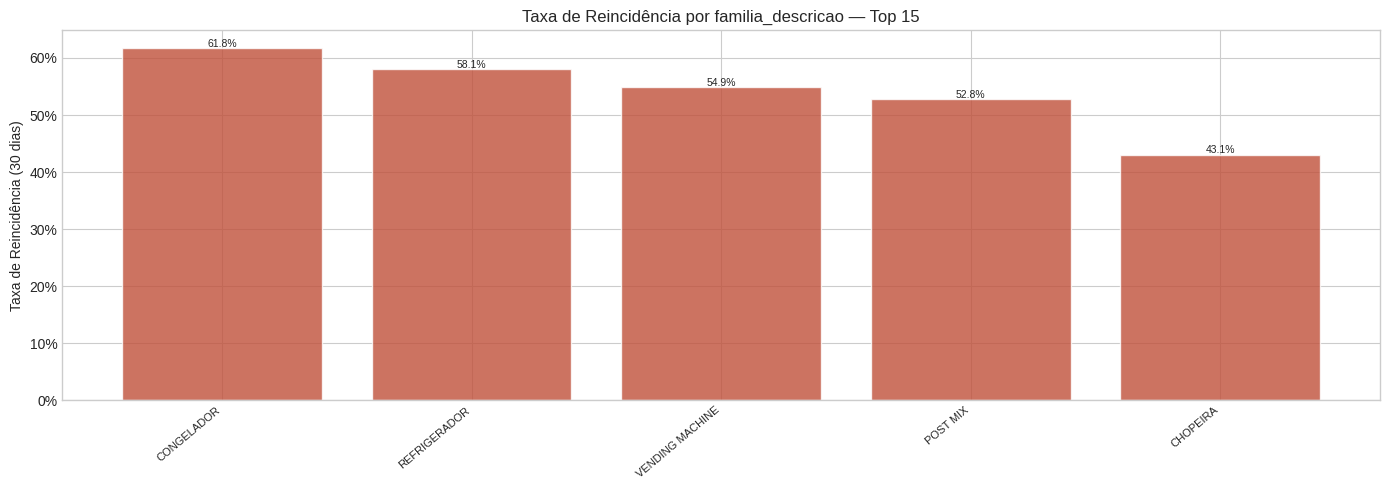

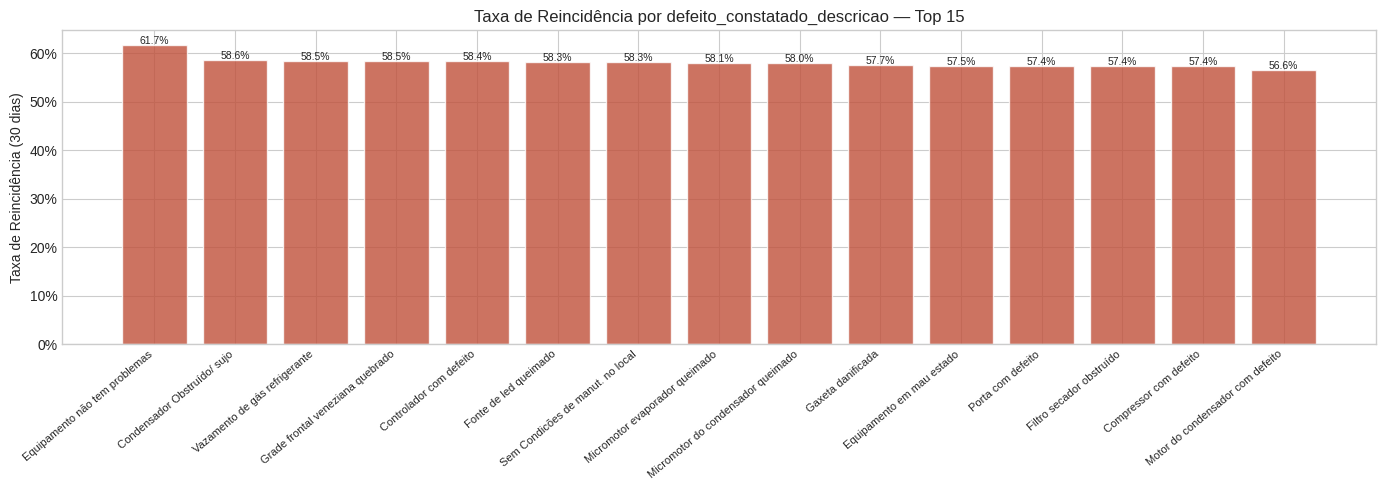

In [13]:
cat_feats = ['familia_descricao', 'defeito_constatado_descricao']

for feat in cat_feats:
    top_cats    = df[feat].value_counts().head(15).index
    reincid_rate = (
        df[df[feat].isin(top_cats)]
          .groupby(feat)['30_dias'].mean()
          .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(reincid_rate)), reincid_rate.values,
                  color='#c0503a', alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(reincid_rate)))
    ax.set_xticklabels(reincid_rate.index, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Taxa de Reincidência (30 dias)')
    ax.set_title(f'Taxa de Reincidência por {feat} — Top 15')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    for bar, v in zip(bars, reincid_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.1%}', ha='center', fontsize=7.5)
    plt.tight_layout()
    plt.show()

### 4.5 Sazonalidade (Reincidência por Mês)

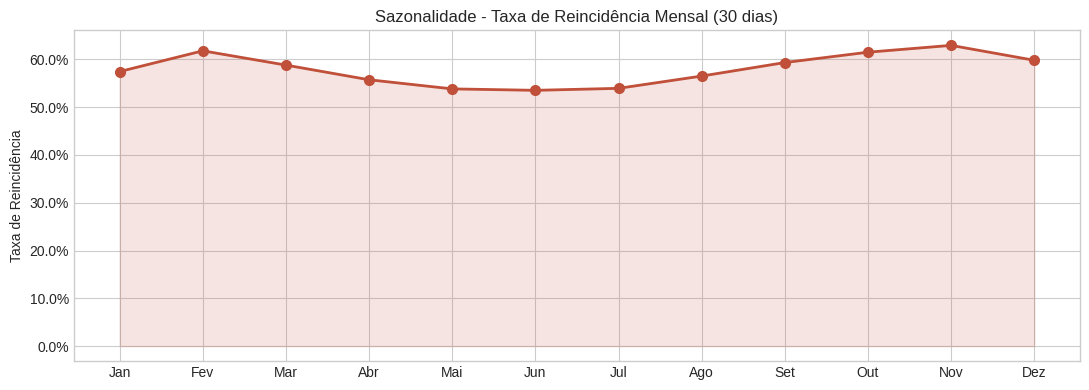

In [14]:
# Análise de sazonalidade mensal
monthly = df.groupby('mes_abertura')['30_dias'].mean().reset_index()
month_names = ['Jan','Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly['mes_abertura'], monthly['30_dias'],
        marker='o', color='#c0503a', linewidth=2, markersize=7)
ax.fill_between(monthly['mes_abertura'], monthly['30_dias'],
                alpha=0.15, color='#c0503a')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Taxa de Reincidência')
ax.set_title('Sazonalidade - Taxa de Reincidência Mensal (30 dias)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.tight_layout()
plt.show()

### 4.6 Matriz de Correlação

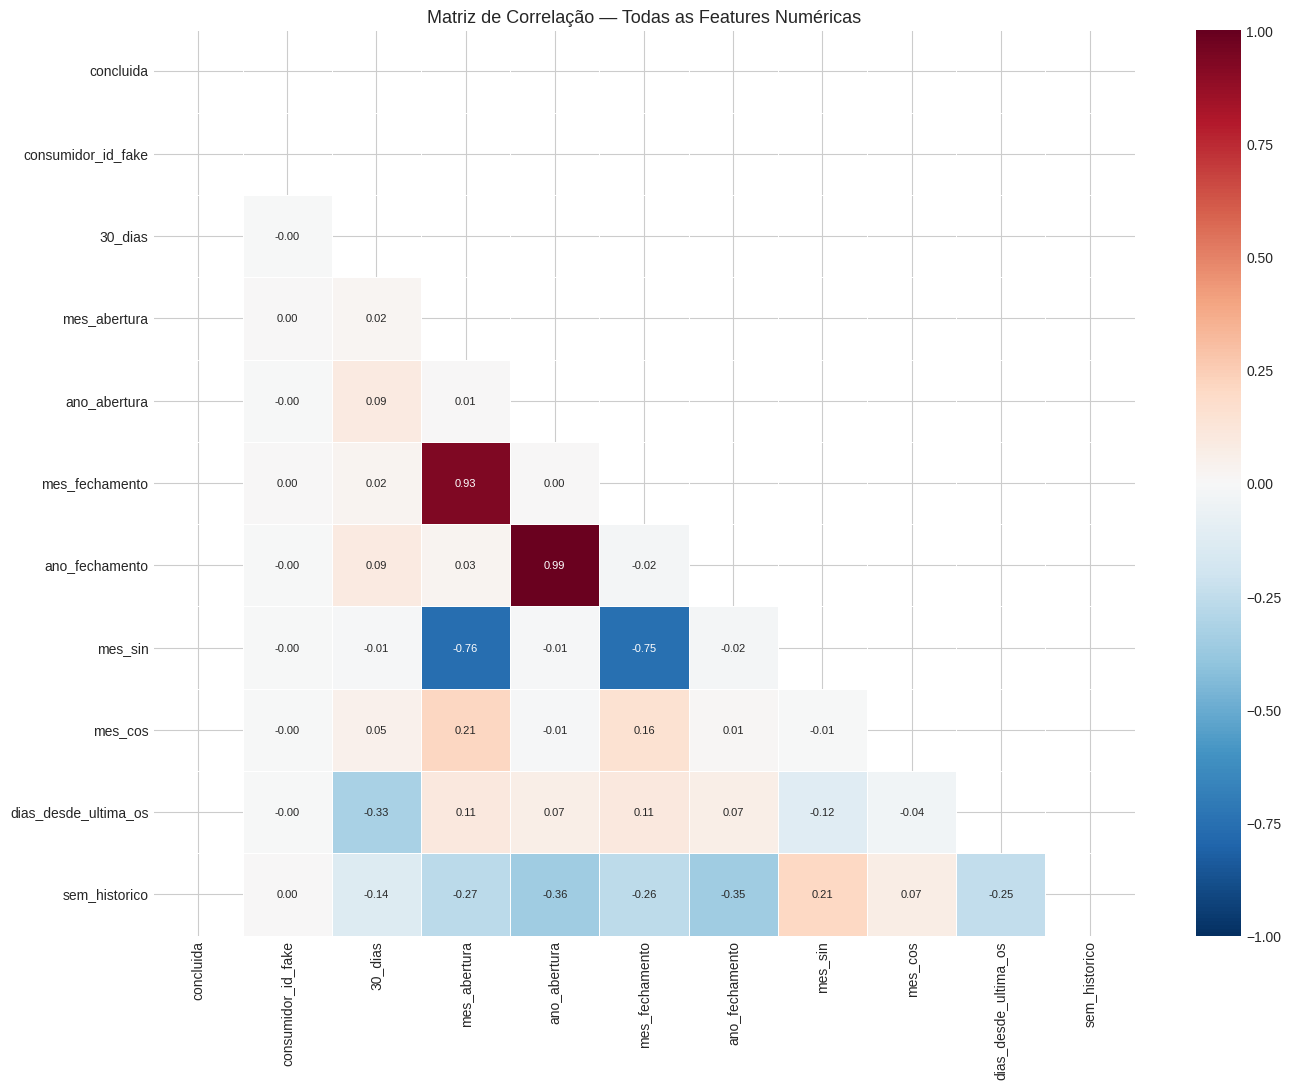

=== CORRELAÇÃO COM 30_dias ===
ano_abertura            0.0894
ano_fechamento          0.0873
mes_cos                 0.0523
mes_fechamento          0.0241
mes_abertura            0.0212
consumidor_id_fake     -0.0016
mes_sin                -0.0103
sem_historico          -0.1356
dias_desde_ultima_os   -0.3264
concluida                  NaN


In [15]:
num_df = df.select_dtypes(include=[np.number])
# Calculando correlação apenas entre features numéricas (excluindo colunas de data e target)
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação — Todas as Features Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

print('=== CORRELAÇÃO COM 30_dias ===')
print(corr['30_dias'].drop('30_dias').sort_values(ascending=False).round(4).to_string())

## 5. Encoding e Normalização

In [16]:
# Preparação para modelagem
scale_cols = [
    'consumidor_id_fake', 'mes_sin', 'mes_cos',
    'dias_desde_ultima_os', 'mes_abertura', 'ano_abertura',
    'mes_fechamento', 'ano_fechamento',
]
le_cols = ['os_id_anonimo', 'familia_descricao', 'defeito_constatado_descricao']

scale = StandardScaler()
le_encoders = {}

for col in le_cols:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col].astype(str))
    le_encoders[col] = enc   # guardar para decode futuro

df[scale_cols] = scale.fit_transform(df[scale_cols])

print('Encoding e normalização aplicados com sucesso!')
print(f'Shape: {df.shape}')
df.head(3)

Encoding e normalização aplicados com sucesso!
Shape: (595710, 14)


,os_id_anonimo,concluida,familia_descricao,defeito_constatado_descricao,consumidor_id_fake,30_dias,mes_abertura,ano_abertura,mes_fechamento,ano_fechamento,mes_sin,mes_cos,dias_desde_ultima_os,sem_historico
0,45187,1,3,161,-1.049685,0,-1.56538,-1.375632,-1.556072,-1.366938,0.714874,1.14096,-0.938398,1
2,456080,1,3,41,1.594472,1,-1.56538,-1.375632,-1.556072,-1.366938,0.714874,1.14096,-0.938398,1
4,24014,1,3,35,-1.462611,1,-1.56538,-1.375632,-1.556072,-1.366938,0.714874,1.14096,-0.938398,1


## 6. Divisão dos Dados - Treino / Validação / Teste

In [17]:
# Separando features e targets
TARGET_COLS = ['30_dias', 'familia_descricao', 'defeito_constatado_descricao']
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS]

X = df[FEATURE_COLS]
y = df[TARGET_COLS]

# 40% treino | 30% validação | 30% teste — estratificado no target primário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.60, random_state=42, stratify=y['30_dias']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp['30_dias']
)

print('=== DIVISÃO DOS DADOS ===')
print(f'Treino:    {len(X_train):>7,} amostras  '
      f'(Reinc={y_train["30_dias"].sum():,} | {y_train["30_dias"].mean():.1%})')
print(f'Validação: {len(X_val):>7,} amostras  '
      f'(Reinc={y_val["30_dias"].sum():,} | {y_val["30_dias"].mean():.1%})')
print(f'Teste:     {len(X_test):>7,} amostras  '
      f'(Reinc={y_test["30_dias"].sum():,} | {y_test["30_dias"].mean():.1%})')
print(f'\nFeatures: {len(FEATURE_COLS)}  |  Targets: {TARGET_COLS}')

=== DIVISÃO DOS DADOS ===
Treino:    238,284 amostras  (Reinc=138,666 | 58.2%)
Validação: 178,713 amostras  (Reinc=104,000 | 58.2%)
Teste:     178,713 amostras  (Reinc=103,999 | 58.2%)

Features: 11  |  Targets: ['30_dias', 'familia_descricao', 'defeito_constatado_descricao']


## 7. Treinamento dos Modelos - MultiOutputClassifier

In [18]:
# Modelos base
dt_base = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# Trocar n_estimators e max_depth para testar diferentes configurações (! Quanto mais n_estimators e max_depth, mais tempo de treino)
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

models_raw = [
    ('Decision Tree', MultiOutputClassifier(dt_base)),
    ('Random Forest', MultiOutputClassifier(rf_base)),
]

for name, model in models_raw:
    model.fit(X_train, y_train)
    print(f'✔ {name} treinado com sucesso!')

✔ Decision Tree treinado com sucesso!
✔ Random Forest treinado com sucesso!


## 8. Avaliação dos Modelos

### 8.1 Métricas por Split - Target Primário (30_dias)

In [19]:
def get_metrics(model, X, y_true, target_idx=0):
    y_pred  = model.predict(X)[:, target_idx]
    y_proba = model.predict_proba(X)[target_idx][:, 1]
    return {
        'Accuracy': accuracy_score(y_true.iloc[:, target_idx], y_pred),
        'Precision': precision_score(y_true.iloc[:, target_idx], y_pred, zero_division=0),
        'Recall': recall_score(y_true.iloc[:, target_idx], y_pred, zero_division=0),
        'F1': f1_score(y_true.iloc[:, target_idx], y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true.iloc[:, target_idx], y_proba),
    }

metrics_val, metrics_test = [], []
for name, model in models_raw:
    metrics_val.append( {'Modelo': name, **get_metrics(model, X_val,  y_val)})
    metrics_test.append({'Modelo': name, **get_metrics(model, X_test, y_test)})

df_val_m  = pd.DataFrame(metrics_val).set_index('Modelo')
df_test_m = pd.DataFrame(metrics_test).set_index('Modelo')

print('=== MÉTRICAS — VALIDAÇÃO (target: 30_dias) ===')
print(df_val_m.round(4).to_string())
print('\n=== MÉTRICAS — TESTE (target: 30_dias) ===')
print(df_test_m.round(4).to_string())

=== MÉTRICAS — VALIDAÇÃO (target: 30_dias) ===
               Accuracy  Precision  Recall      F1     AUC
Modelo                                                    
Decision Tree    0.7727     0.9948  0.6127  0.7583  0.8271
Random Forest    0.7728     0.9955  0.6124  0.7583  0.8273

=== MÉTRICAS — TESTE (target: 30_dias) ===
               Accuracy  Precision  Recall      F1     AUC
Modelo                                                    
Decision Tree    0.7712     0.9951  0.6099  0.7563  0.8262
Random Forest    0.7711     0.9955  0.6094  0.7560  0.8256


### 8.2 Gráfico Comparativo de Métricas

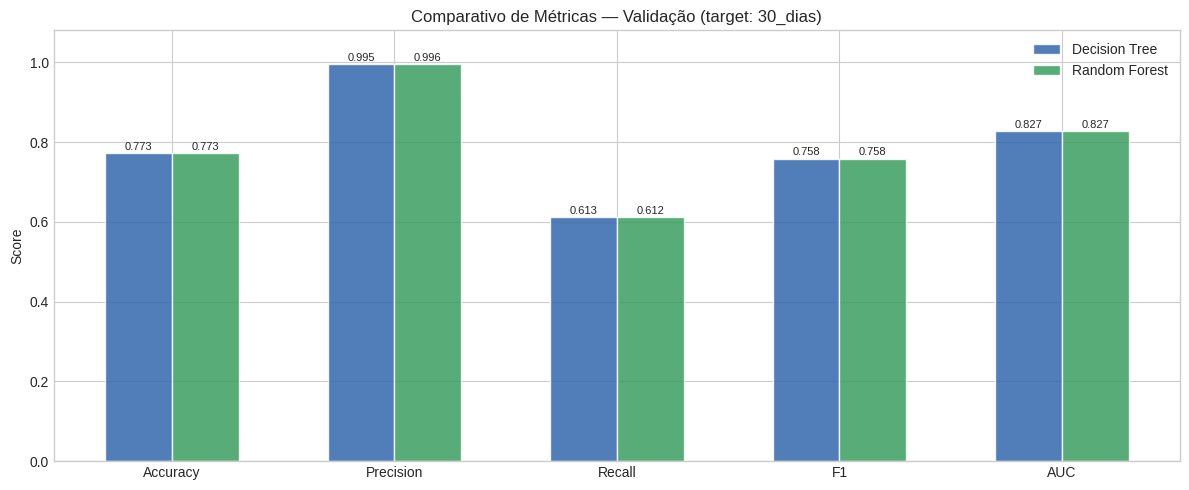

In [20]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_names = df_val_m.index.tolist()
palette     = ['#3266ad', '#3a9e5f']

x = np.arange(len(metric_cols))
w = 0.30

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(model_names, palette)):
    offset = (i - (len(model_names) - 1) / 2) * w
    vals   = df_val_m.loc[name, metric_cols].values
    bars   = ax.bar(x + offset, vals, w, label=name,
                    color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_title('Comparativo de Métricas — Validação (target: 30_dias)')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

### 8.3 Matrizes de Confusão

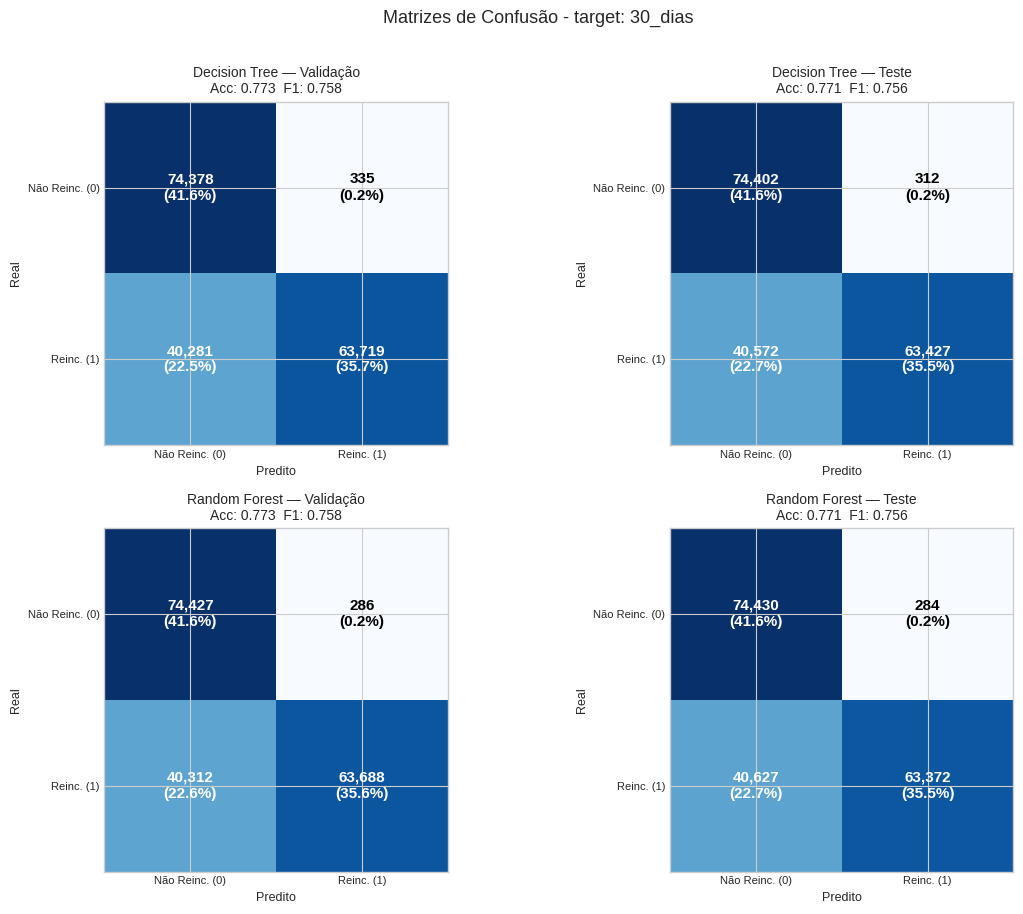

In [21]:
def plot_confusion_matrices(models_list, X_v, y_v, X_te, y_te,
                             target_idx=0, target_name='30_dias'):
    n     = len(models_list)
    fig, axes = plt.subplots(n, 2, figsize=(12, n * 4 + 1))
    if n == 1:
        axes = [axes]
    class_names = ['Não Reinc. (0)', 'Reinc. (1)']

    for row, (name, model) in enumerate(models_list):
        for col, (Xd, yt, split_name) in enumerate([
            (X_v,  y_v,  'Validação'),
            (X_te, y_te, 'Teste')
        ]):
            y_pred = model.predict(Xd)[:, target_idx]
            y_true = yt.iloc[:, target_idx]
            cm     = confusion_matrix(y_true, y_pred)
            ax     = axes[row][col]

            ax.imshow(cm, cmap='Blues')
            for i in range(2):
                for j in range(2):
                    pct   = cm[i, j] / cm.sum() * 100
                    color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
                    ax.text(j, i, f'{cm[i,j]:,}\n({pct:.1f}%)',
                            ha='center', va='center', color=color,
                            fontsize=11, fontweight='bold')

            ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
            ax.set_xticklabels(class_names, fontsize=8)
            ax.set_yticklabels(class_names, fontsize=8)
            ax.set_xlabel('Predito', fontsize=9)
            ax.set_ylabel('Real', fontsize=9)
            acc = accuracy_score(y_true, y_pred)
            f1  = f1_score(y_true, y_pred, zero_division=0)
            ax.set_title(f'{name} — {split_name}\nAcc: {acc:.3f}  F1: {f1:.3f}', fontsize=10)

    plt.suptitle(f'Matrizes de Confusão - target: {target_name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(models_raw, X_val, y_val, X_test, y_test)

### 8.4 Curvas ROC / AUC

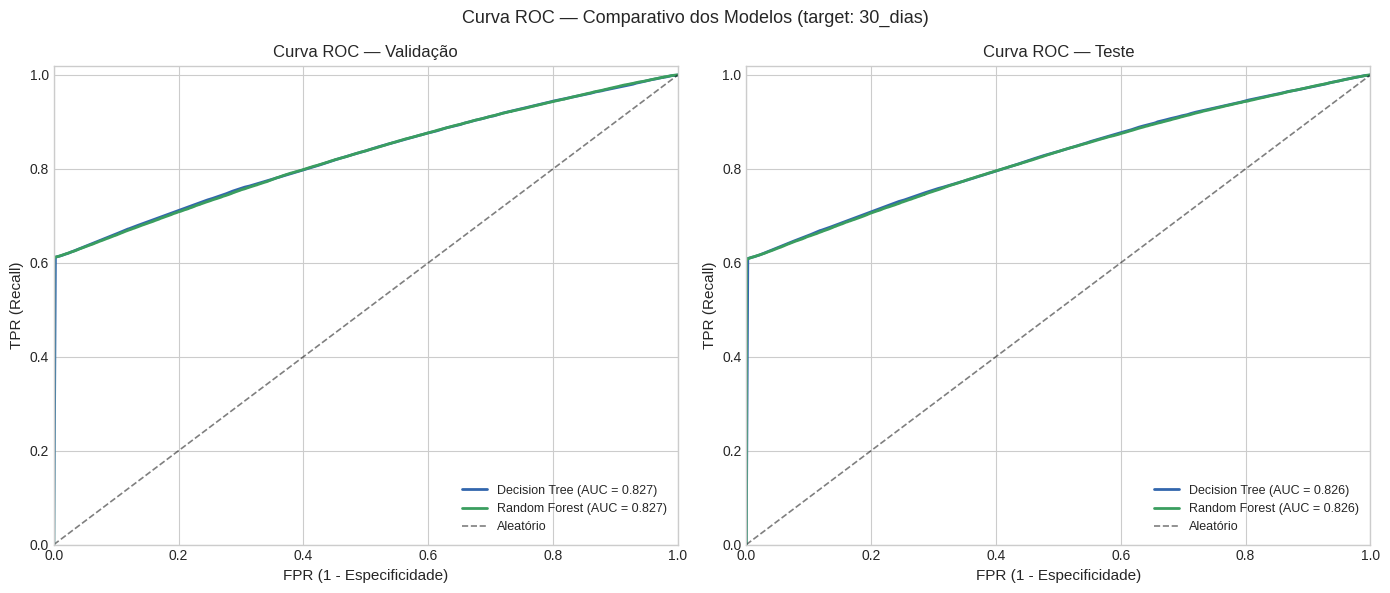

In [22]:
palette = ['#3266ad', '#3a9e5f']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (Xd, yt, split_name) in zip(axes, [
    (X_val,  y_val,  'Validação'),
    (X_test, y_test, 'Teste')
]):
    for (name, model), color in zip(models_raw, palette):
        y_proba = model.predict_proba(Xd)[0][:, 1]
        y_true  = yt.iloc[:, 0]
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Aleatório')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('FPR (1 - Especificidade)', fontsize=11)
    ax.set_ylabel('TPR (Recall)', fontsize=11)
    ax.set_title(f'Curva ROC — {split_name}')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Curva ROC — Comparativo dos Modelos (target: 30_dias)', fontsize=13)
plt.tight_layout()
plt.show()

### 8.5 Análise Detalhada - Classification Report

In [23]:
for name, model in models_raw:
    print(f"{'='*65}")
    print(f'  {name}  —  target: 30_dias')
    print(f"{'='*65}")
    for Xd, yt, split_name in [(X_val, y_val, 'VALIDAÇÃO'), (X_test, y_test, 'TESTE')]:
        y_pred = model.predict(Xd)[:, 0]
        y_true = yt.iloc[:, 0]
        print(f'--- {split_name} ---')
        print(classification_report(y_true, y_pred,
              target_names=['Não Reinc.', 'Reinc.'], digits=4))
    print()

  Decision Tree  —  target: 30_dias
--- VALIDAÇÃO ---
              precision    recall  f1-score   support

  Não Reinc.     0.6487    0.9955    0.7855     74713
      Reinc.     0.9948    0.6127    0.7583    104000

    accuracy                         0.7727    178713
   macro avg     0.8217    0.8041    0.7719    178713
weighted avg     0.8501    0.7727    0.7697    178713

--- TESTE ---
              precision    recall  f1-score   support

  Não Reinc.     0.6471    0.9958    0.7845     74714
      Reinc.     0.9951    0.6099    0.7563    103999

    accuracy                         0.7712    178713
   macro avg     0.8211    0.8029    0.7704    178713
weighted avg     0.8496    0.7712    0.7681    178713


  Random Forest  —  target: 30_dias
--- VALIDAÇÃO ---
              precision    recall  f1-score   support

  Não Reinc.     0.6487    0.9962    0.7857     74713
      Reinc.     0.9955    0.6124    0.7583    104000

    accuracy                         0.7728    178713
   ma

### 8.6 Importância de Features - Random Forest

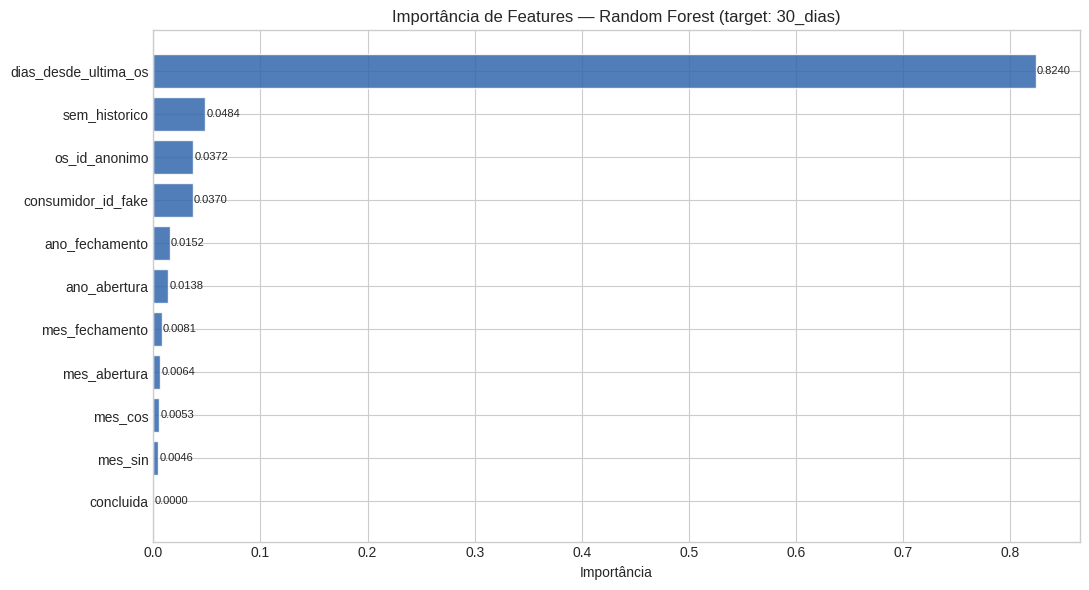

=== TOP 10 FEATURES ===
  dias_desde_ultima_os                     0.8240
  sem_historico                            0.0484
  os_id_anonimo                            0.0372
  consumidor_id_fake                       0.0370
  ano_fechamento                           0.0152
  ano_abertura                             0.0138
  mes_fechamento                           0.0081
  mes_abertura                             0.0064
  mes_cos                                  0.0053
  mes_sin                                  0.0046


In [24]:
rf_model = dict(models_raw)['Random Forest']
rf_primary = rf_model.estimators_[0]

feat_imp = pd.Series(rf_primary.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color='#3266ad', alpha=0.85, edgecolor='white')
for bar, v in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)

ax.set_xlabel('Importância')
ax.set_title('Importância de Features — Random Forest (target: 30_dias)')
plt.tight_layout()
plt.show()

print('=== TOP 10 FEATURES ===')
for feat, imp in feat_imp.head(10).items():
    print(f'  {feat:<40} {imp:.4f}')

### 8.7 Métricas dos Outputs Secundários

In [25]:
TARGET_COLS = ['30_dias', 'familia_descricao', 'defeito_constatado_descricao']

print('=== MÉTRICAS MULTI-OUTPUT — TESTE ===')
print(f'{"Modelo":<22} {"Output":<35} {"Accuracy":>10} {"F1-Macro":>10}')
print('-' * 82)

for name, model in models_raw:
    y_pred_all = model.predict(X_test)
    for t_idx, t_name in enumerate(TARGET_COLS):
        y_true_t = y_test.iloc[:, t_idx].values
        y_pred_t = y_pred_all[:, t_idx]
        acc = accuracy_score(y_true_t, y_pred_t)
        f1  = f1_score(y_true_t, y_pred_t, average='macro', zero_division=0)
        print(f'{name:<22} {t_name:<35} {acc:>10.4f} {f1:>10.4f}')
    print()

=== MÉTRICAS MULTI-OUTPUT — TESTE ===
Modelo                 Output                                Accuracy   F1-Macro
----------------------------------------------------------------------------------
Decision Tree          30_dias                                 0.7712     0.7704
Decision Tree          familia_descricao                       0.3106     0.1508
Decision Tree          defeito_constatado_descricao            0.0010     0.0021

Random Forest          30_dias                                 0.7711     0.7702
Random Forest          familia_descricao                       0.7554     0.2226
Random Forest          defeito_constatado_descricao            0.0118     0.0050



## 9. Tabela Comparativa Final

In [26]:
print('=== TABELA COMPARATIVA — VALIDAÇÃO (target primário: 30_dias) ===')
print(df_val_m.round(4).to_string())

print('\n=== TABELA COMPARATIVA — TESTE (target primário: 30_dias) ===')
print(df_test_m.round(4).to_string())

print('\n=== MELHOR MODELO POR MÉTRICA (VALIDAÇÃO) ===')
for col in df_val_m.columns:
    best = df_val_m[col].idxmax()
    print(f'  {col:>12}: {best} ({df_val_m.loc[best, col]:.4f})')

print('\n=== RECOMENDAÇÃO ===')
best_f1     = df_val_m['F1'].idxmax()
best_recall = df_val_m['Recall'].idxmax()
print(f'  Melhor F1 na classe Reinc.:    {best_f1}')
print(f'  Melhor Recall na classe Reinc: {best_recall}')
print('  !!! Para uso em produção, priorizar Recall (minimizar falsos negativos).')

=== TABELA COMPARATIVA — VALIDAÇÃO (target primário: 30_dias) ===
               Accuracy  Precision  Recall      F1     AUC
Modelo                                                    
Decision Tree    0.7727     0.9948  0.6127  0.7583  0.8271
Random Forest    0.7728     0.9955  0.6124  0.7583  0.8273

=== TABELA COMPARATIVA — TESTE (target primário: 30_dias) ===
               Accuracy  Precision  Recall      F1     AUC
Modelo                                                    
Decision Tree    0.7712     0.9951  0.6099  0.7563  0.8262
Random Forest    0.7711     0.9955  0.6094  0.7560  0.8256

=== MELHOR MODELO POR MÉTRICA (VALIDAÇÃO) ===
      Accuracy: Random Forest (0.7728)
     Precision: Random Forest (0.9955)
        Recall: Decision Tree (0.6127)
            F1: Decision Tree (0.7583)
           AUC: Random Forest (0.8273)

=== RECOMENDAÇÃO ===
  Melhor F1 na classe Reinc.:    Decision Tree
  Melhor Recall na classe Reinc: Decision Tree
  !!! Para uso em produção, priorizar Rec

In [29]:

# 1. Encontrar o melhor modelo (Decision Tree) dentro da lista models_raw
melhor_modelo_nome = 'Decision Tree'
modelo_para_salvar = None

for name, model in models_raw:
    if name == melhor_modelo_nome:
        modelo_para_salvar = model
        break

# 2. Exportar o modelo treinado para o arquivo .joblib
if modelo_para_salvar is not None:
    nome_arquivo = 'melhor_modelo_projeto9_v2.joblib'
    
    try:
        # compress=3 aplica uma compressão leve ideal para árvores/florestas sem perder desempenho
        joblib.dump(modelo_para_salvar, nome_arquivo, compress=3)
        print(f"✅ Sucesso! O melhor modelo ({melhor_modelo_nome}) foi salvo!")
        print(f"📍 Caminho do arquivo: {os.path.abspath(nome_arquivo)}")
        
    except Exception as e:
        print(f"❌ Erro ao salvar o modelo: {e}")
else:
    print(f"⚠️ O modelo '{melhor_modelo_nome}' não foi encontrado na lista 'models_raw'. Verifique se os modelos foram treinados.")

✅ Sucesso! O melhor modelo (Decision Tree) foi salvo!
📍 Caminho do arquivo: /home/victor/workspace/fabrica-de-projetos-3/melhor_modelo_projeto9_v2.joblib
